In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# пункт 2

In [2]:
data2 = pd.read_csv("data2.csv")
data2

,U_a,U_out,A,f
0,8.6,2.5400,29775.00,50
1,16.5,2.5450,15456.00,100
2,35.0,2.5490,7342.00,200
3,89.5,2.5350,2855.00,500
4,176.0,2.4900,1426.00,1000
5,321.0,2.3000,722.00,2000
6,590.0,1.7250,294.00,5000
7,742.0,1.0550,143.00,10000
8,780.0,0.5450,70.00,20000
9,795.0,0.2220,28.00,50000


In [3]:
data2["lgA"] = 20 * np.log10(data2["A"])

In [4]:
def linear(x, k, b):
    return k*x + b

f_rho0 = 1658688
f_T = 1185545


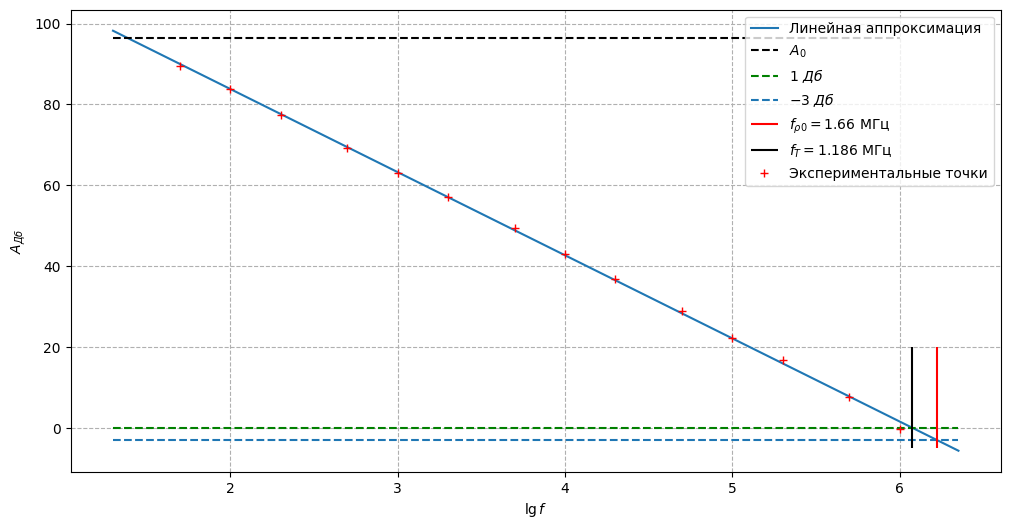

In [5]:
plt.figure(figsize=(12, 6))

A_0 = 20*np.log10(66_272)
A_1 = 20*np.log10(1)

x = np.log10(data2["f"])
y = data2["lgA"]


popt, pcov = curve_fit(linear, xdata=x, ydata=y)
k, b = popt

x_model = np.linspace(min(x)-0.4, max(x)+0.35, 10000)
y_model = linear(x_model, k, b)


plt.plot(x_model, y_model, label="Линейная аппроксимация")


plt.errorbar(x=x, y=y, fmt="+r", label="Экспериментальные точки")


plt.hlines(y=A_0, xmin=min(x)-0.4, xmax=max(x), linestyles="--", label=r"$A_0$", colors="black")
plt.hlines(y=A_1, xmin=min(x)-0.4, xmax=max(x)+0.35, linestyles="--", label=r"$1~Дб$", colors="green")
plt.hlines(y=-3, xmin=min(x)-0.4, xmax=max(x)+0.35, linestyles="--", label=r"$-3~Дб$")


# kx + b = -3
# x = (-3 - b) / k
lg_f_rho0 = (-3 - b) / k
f_rho0 = np.pow(10, lg_f_rho0)
print(f"f_rho0 = {f_rho0:.0f}")
plt.vlines(x=lg_f_rho0, ymin=-5, ymax=20, colors="red", label=r"$f_{\rho 0} = 1.66~\text{МГц}$")


# kx + b = 0
# x = - b / k
lg_f_T = - b / k
f_T = np.pow(10, lg_f_T)
print(f"f_T = {f_T:.0f}")
plt.vlines(x=lg_f_T, ymin=-5, ymax=20, colors="black", label=r"$f_T = 1.186~\text{МГц}$")



plt.grid(True, linestyle='--')
plt.xlabel(r"$\lg f$")
plt.ylabel(r"$A_{Дб}$")



plt.legend()
plt.savefig("pictures/graph_achx.pdf")
plt.show()

# пункт 3

In [6]:
data3 = pd.read_csv("data3.csv")
data3

,U_out,f,K
0,5.00,1.00,98
1,5.27,2.00,103
2,5.21,3.00,102
3,5.12,4.00,100
4,5.01,5.00,98
5,4.89,6.00,96
6,4.75,7.00,93
7,4.61,8.00,90
8,4.47,9.00,88
9,4.33,10.00,85


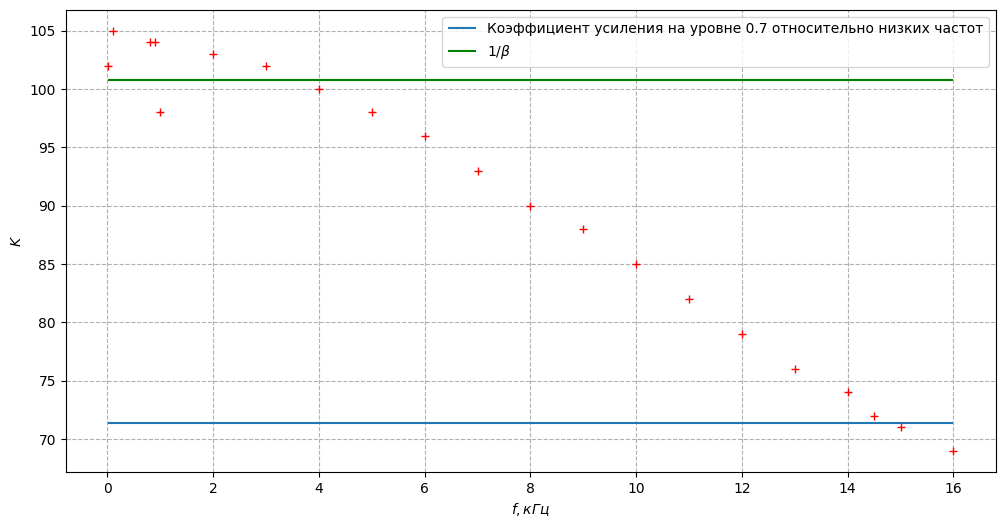

In [7]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle='--')


plt.errorbar(x=data3["f"], y=data3["K"], fmt="+r")



plt.hlines(y=102*0.7, xmin=min(data3["f"]), xmax=max(data3["f"]), label="Коэффициент усиления на уровне 0.7 относительно низких частот")

beta = np.float128("9.92e-3")
plt.hlines(y=1/beta, xmin=min(data3["f"]), xmax=max(data3["f"]), colors="green", label=r"$1 / \beta$")


# F_p = beta * f_T / 1e3
# plt.vlines(x=F_p, ymin=min(data3["K"]), ymax=max(data3["K"]), colors="green", label=r"$1 / \beta$")


plt.xlabel(r"$f, кГц$")
plt.ylabel(r"$K$")


plt.legend()
plt.savefig("pictures/graph_K_f.pdf")
plt.show()

# Пункт 8

In [8]:
data8 = pd.read_csv("data8.csv")
data8

,hat_a,A_out,f,K
0,444,3760,5,8.47
1,444,3760,10,8.47
2,444,3526,15,7.94
3,444,3222,20,7.26
4,444,3100,22,6.98
5,300,1300,50,4.33
6,300,503,150,1.68
7,300,306,250,1.02
8,300,224,350,0.75
9,300,174,450,0.58


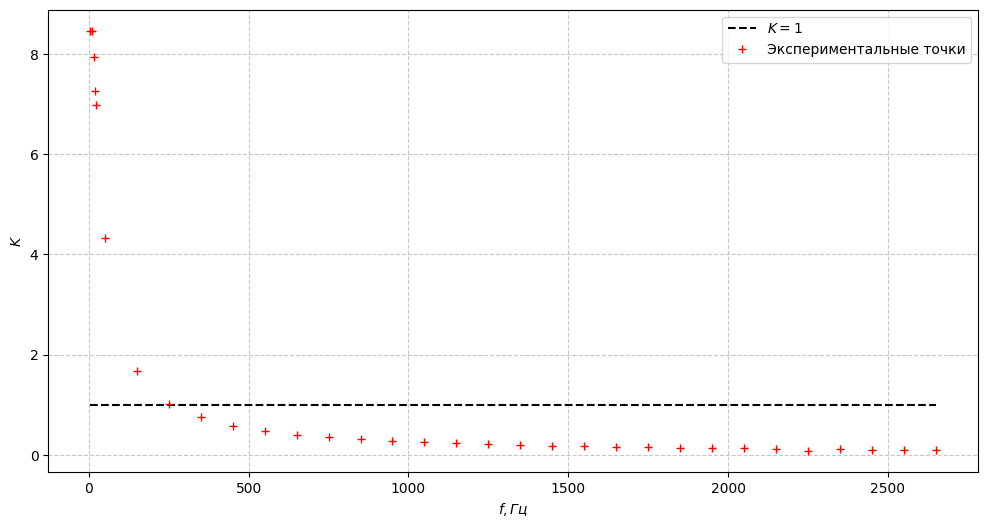

In [9]:
plt.figure(figsize=(12, 6))

plt.errorbar(x=data8["f"], y=data8["K"], fmt='+r', label="Экспериментальные точки")

plt.hlines(y=1, xmin=min(data8["f"]), xmax=max(data8["f"]), label="$K = 1$", linestyles='--', colors="black")


plt.xlabel(r"$f, Гц$")
plt.ylabel(r"$K$")
plt.grid(True, which='both', linestyle='--', alpha=0.7)

plt.legend()
plt.savefig("pictures/graph_achx_8.pdf")
plt.show()

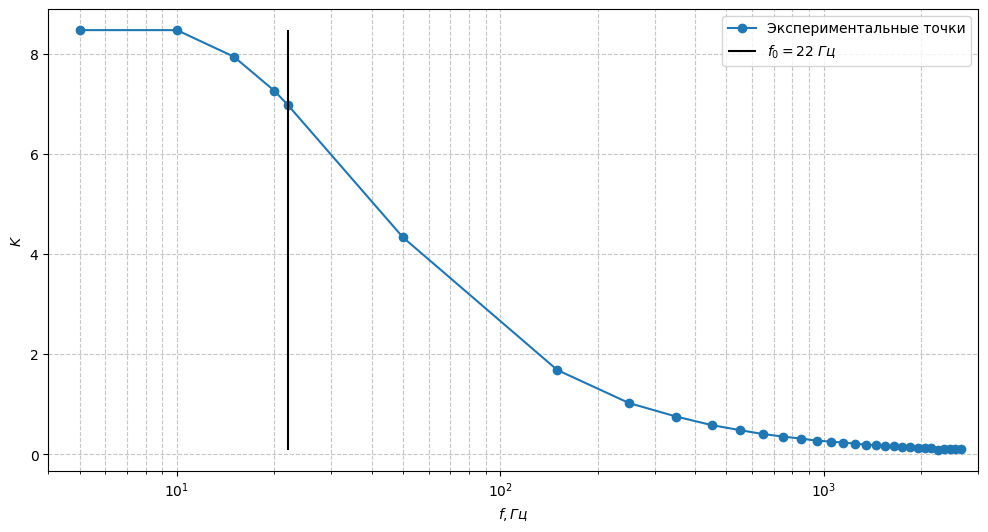

In [12]:
f = np.array(data8["f"])
K = np.array(data8["K"])

plt.figure(figsize=(12, 6))

plt.semilogx(f, K, marker='o', linestyle='-', label="Экспериментальные точки")


plt.vlines(x=22, ymin=min(K), ymax=max(K), colors="black", label=r"$f_0 = 22 ~ Гц$")
plt.xlim((4, 0.3e4))

plt.xlabel(r"$f, Гц$")
plt.ylabel(r"$K$")
plt.grid(True, which='both', linestyle='--', alpha=0.7)

plt.legend()
plt.savefig("pictures/graph_bodee.pdf")
plt.show()